In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import db_dtypes

In [2]:
client = bigquery.Client(project='first-project-321219')

query = """
With events as (
      SELECT  
      -- event_id 8, 11 have same session_id. if i use event_id, it cause duplicate session
            e1.id AS event_id,
            e1.session_id,
            e1.user_id,
            e1.created_at AS cart_created_at,
            e2.created_at AS purchase_created_at,
            CASE WHEN e2.id IS NOT NULL THEN 1 ELSE 0 END AS purchase_label,
            e1.city,
            e1.state, 
            e1.browser,
            e1.traffic_source,
            u.age,
            u.gender,
            u.country

      FROM `bigquery-public-data.thelook_ecommerce.events` e1
      LEFT JOIN `bigquery-public-data.thelook_ecommerce.events` e2 ON e1.session_id = e2.session_id
                                                                  --on e1.user_id = e2.user_id 27/01/2026: change to join session_id as purchase should happen within one session
                                                                  and e2.event_type =  'purchase' 
                                                                --  and e2.created_at>e1.created_at 
                                                                --  and TIMESTAMP_DIFF(e2.created_at, e1.created_at, DAY) <=7
      LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` u on e1.user_id = u.id
      WHERE e1.event_type = 'cart'
            AND e1.created_at >='2024-01-01'
)


SELECT --event_id,
        DISTINCT
        session_id,
         user_id,
         city,
         state,
         browser,
         traffic_source,
         age,
         country,
         max(cart_created_at) as cart_created_date,
        -- CASE WHEN IFNULL(sum(purchase_label),0)>0 THEN 1 ELSE 0 END AS purchased_flag_1,
         MAX(purchase_label) AS purchased_flag  
         
FROM events

--where session_id = 'f8dc71e1-6091-45e9-92ed-d174ee90cd12'

GROUP BY 1,2,3,4,5,6,7,8

"""

df = client.query(query).to_dataframe()
print(df.head())

                             session_id  user_id                 city  \
0  7126e450-b7b3-4ba3-889d-6aa12b57ead0    65094  Gorzów Wielkopolski   
1  b99c8fc9-a1e8-45f9-93ec-30672a48d210    88577  Gorzów Wielkopolski   
2  c803860b-7b90-4f42-b9c2-37aba71cb0b4    23423         Schwedt/Oder   
3  a2309240-a1a7-4f3e-9d3c-9f930b2100aa    46726         Schwedt/Oder   
4  b5d14ab6-9e49-4ca6-865c-3da6a2febaa9    76251            Bogatynia   

                state  browser traffic_source  age country  \
0            Lubuskie  Firefox          Email   15  Poland   
1            Lubuskie   Chrome        Adwords   31  Poland   
2  Zachodniopomorskie   Chrome        Adwords   22  Poland   
3  Zachodniopomorskie  Firefox        Adwords   60  Poland   
4        Dolnośląskie   Safari          Email   34  Poland   

                 cart_created_date  purchased_flag  
0        2025-07-03 04:32:07+00:00               1  
1        2024-05-22 06:35:18+00:00               1  
2        2025-12-12 14:04:46+

In [3]:
# SQL query: can add more feature from product and order table

In [4]:
def load_data(dataframe, datefrom = None, dateto = None):
    
    if not isinstance(dataframe, pd.DataFrame):   #isinstance(): check specified object is in specificed type.
        print('Error: Input is not a DataFrame')
        return None
  

    if 'purchased_flag' not in dataframe.columns: 
        print(f'Column Error: purchased_flag is not in DataFrame')
        return dataframe
        
    try:
        dataframe['cart_created_date'] = pd.to_datetime(dataframe['cart_created_date'])
    except Exception:
        print(f'Date Conversion Error: {Exception}')

    return dataframe

    

In [5]:
df_initial = load_data(df)
df_initial[df_initial['age'].isna()]

,session_id,user_id,city,state,browser,traffic_source,age,country,cart_created_date,purchased_flag
248,79f3a4e9-3307-46fb-ab12-3e90eeb75093,<NA>,São Paulo,São Paulo,Chrome,Adwords,<NA>,None,2024-06-16 04:09:00+00:00,0
249,78f46bb1-d100-4ca7-906e-50bd6e6c7e7b,<NA>,São Paulo,São Paulo,Chrome,YouTube,<NA>,None,2024-11-23 05:37:00+00:00,0
250,99a2e5a8-9f4c-4406-8892-c32ec7996a96,<NA>,São Paulo,São Paulo,Safari,Adwords,<NA>,None,2025-01-22 12:00:00+00:00,0
251,5c8b891d-e698-4fc8-8d57-4d67d1b32c5d,<NA>,São Paulo,São Paulo,Safari,YouTube,<NA>,None,2025-05-14 13:08:00+00:00,0
252,5a14b598-317d-42fd-910a-d7e51594f1b8,<NA>,Huludao,Beijing,Chrome,Email,<NA>,None,2024-04-26 01:39:00+00:00,0
...,...,...,...,...,...,...,...,...,...,...
73125,56398654-d640-4a7f-828e-e5da49e30fe5,<NA>,Wath upon Dearne,England,Firefox,Adwords,<NA>,None,2024-01-25 07:06:00+00:00,0
73126,3ce62052-bc5a-4508-b2c4-0f70b7fd2d01,<NA>,Llandybïe,Wales,Chrome,Adwords,<NA>,None,2025-05-24 01:13:00+00:00,0
73127,a2efcc3a-3ee4-4168-b3dc-c63d0f86440e,<NA>,Southend-on-Sea,England,IE,YouTube,<NA>,None,2024-08-08 16:09:00+00:00,0
73128,9d3a4f8c-5926-4876-846e-cd486a264d80,<NA>,Leek,England,Chrome,YouTube,<NA>,None,2024-07-12 03:24:00+00:00,0


In [6]:
df_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192919 entries, 0 to 192918
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   session_id         192919 non-null  object             
 1   user_id            120037 non-null  Int64              
 2   city               192919 non-null  object             
 3   state              192919 non-null  object             
 4   browser            192919 non-null  object             
 5   traffic_source     192919 non-null  object             
 6   age                120037 non-null  Int64              
 7   country            120037 non-null  object             
 8   cart_created_date  192919 non-null  datetime64[us, UTC]
 9   purchased_flag     192919 non-null  Int64              
dtypes: Int64(3), datetime64[us, UTC](1), object(6)
memory usage: 15.3+ MB


In [7]:
df_initial['purchased_flag'].value_counts()

purchased_flag
1    120037
0     72882
Name: count, dtype: Int64

In [30]:
df_initial['state'].nunique()

231

In [39]:
from collections import Counter

def prepare_data(df_input, target = 'purchased_flag', random_state = 42):

    df=df_input.copy()

    #df = df.dropna(subset = ['user_id']).copy()
    # España is same meaning as Spain. replace it
   
    df['country'] = df['country'].replace(
                                            {'España': 'Spain', 
                                             'Deutschland': 'Germany'},regex = False)
    #df['user_id'] = df['user_id'].fillna(-1)
    #if it is null in user_id, return 1
    df['is_guest'] = df['user_id'].isnull().astype(int)
    df['age'] = df['age'].fillna(-1)
    df['country'] = df['country'].fillna('Unknown')
    
    df[target] = df[target].fillna(0).astype(int)
   
    # 28/01/2026:JI: test remove different field and the impact of modelling.
    cols = ['session_id', 'user_id', 'city', 'state', 'cart_created_date', 'purchased_flag', 'is_guest', 'age','country']
    #cols = ['session_id', 'user_id', 'city', 'state', 'cart_created_date', 'purchased_flag']
    
    X = df[[c for c in df.columns if c not in cols]]
    y = df[target]


    X = pd.get_dummies(X, drop_first = True, dtype = int) # use drop_true reduce multicollinearity
  
    print(f'purchased_flag {Counter(y)}')
    df_final = X
    df_final[target] = y
    
    return df_final
    
  

In [40]:
df_prep = prepare_data(df_initial)
df_prep

purchased_flag Counter({1: 120037, 0: 72882})


,browser_Firefox,browser_IE,browser_Other,browser_Safari,traffic_source_Email,traffic_source_Facebook,traffic_source_Organic,traffic_source_YouTube,purchased_flag
0,1,0,0,0,1,0,0,0,1
1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,1
4,0,0,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...
192914,0,0,0,0,1,0,0,0,1
192915,0,0,0,1,1,0,0,0,1
192916,0,0,0,0,0,0,0,0,1
192917,0,0,0,0,0,0,0,0,1


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler


def logistics_regression(df, target = 'purchased_flag', test_size = 0.2, random_state = 16):
    
    feature_cols = [c for c in df.columns if c != 'purchased_flag']
    X = df[feature_cols]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, random_state = random_state)


    # Standarise features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # train model
    logreg = LogisticRegression(class_weight = 'balanced', random_state = random_state, max_iter = 1000)
   
    # max_tier: maximum of 1000 iterations to find the optimal set of coefficients (parameters). 

    # fit the model with data
    logreg.fit(X_train_scaled, y_train)

    y_pred = logreg.predict(X_test_scaled)

    # model evaluation by using confusion matrix

    confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

    # plot Confusion Matrix chart
    class_names = [0,1]
    fig, ax = plt.subplots()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)

    sns.heatmap(pd.DataFrame(confusion_matrix), annot = True, cmap = 'YlGnBu', fmt = 'g')
    plt.tight_layout()
    plt.title('Confusion Matrix')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

    # print classifiction report
    print(classification_report(y_test, y_pred, target_names = ['not purchased', 'purchased']))

    # plot ROC curve
    y_pred_proba = logreg.predict_proba(X_test_scaled)[:,1] # the probability of positive label
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)
    auc = metrics.roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label='purchased flag is 1, auc='+str(auc))
    plt.plot([0,1], [0,1], 'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': logreg.coef_[0]})

    coef_df = coef_df.sort_values(by = 'Coefficient', ascending = False)
    print(coef_df)

    return logreg, auc, y_test, y_pred_proba

    

In [11]:
#If I drop user_id is null, the remained data only include purchased_flag = 1. it's because customers need to login when they want to purchase. 
#The model will return ValueError: This solver needs samples of at least 2 classes

#If I keep the user_id null value, the precision, recall will be 1 because it feature leakage. when is_guest = 1, purcahse_flag = 0
# is_guest is a feature leakage. when is_guest = 1, the model knows purchased_flag is 0. when is_guest = 0, the model knows purchased_flag = 1

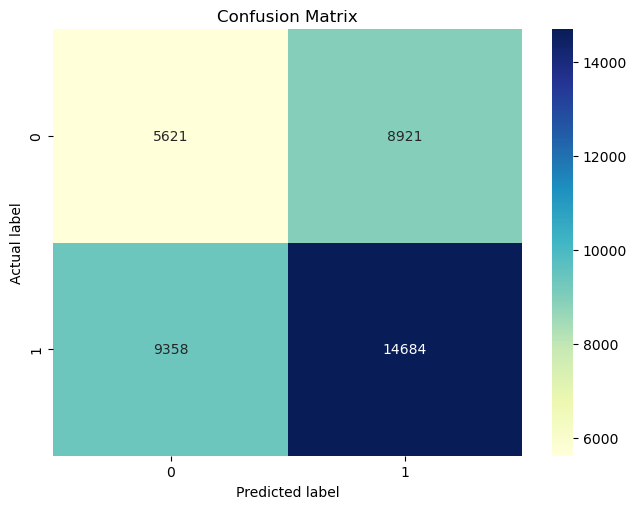

               precision    recall  f1-score   support

not purchased       0.38      0.39      0.38     14542
    purchased       0.62      0.61      0.62     24042

     accuracy                           0.53     38584
    macro avg       0.50      0.50      0.50     38584
 weighted avg       0.53      0.53      0.53     38584



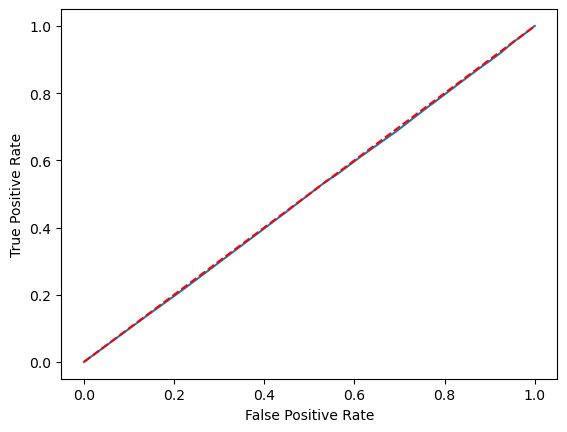

                   Feature  Coefficient
0          browser_Firefox    -0.001195
1               browser_IE    -0.001507
5  traffic_source_Facebook    -0.006656
4     traffic_source_Email    -0.007138
6   traffic_source_Organic    -0.009086
7   traffic_source_YouTube    -0.010263
3           browser_Safari    -0.010735
2            browser_Other    -0.013617


In [41]:
df_logreg = logistics_regression(df_prep)